In [35]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [36]:
#import the flat data from the fits file
flat_hudl = fits.open('data/flat.fits')
flat_data = flat_hudl[0].data
print(flat_data.shape)

(4112, 385)


In [37]:
#quickly visualise the data to find tramtracks
plt.imshow(flat_data,aspect = 'auto',cmap = 'grey')

In [38]:
#set matplotlib backend
%matplotlib widget

0

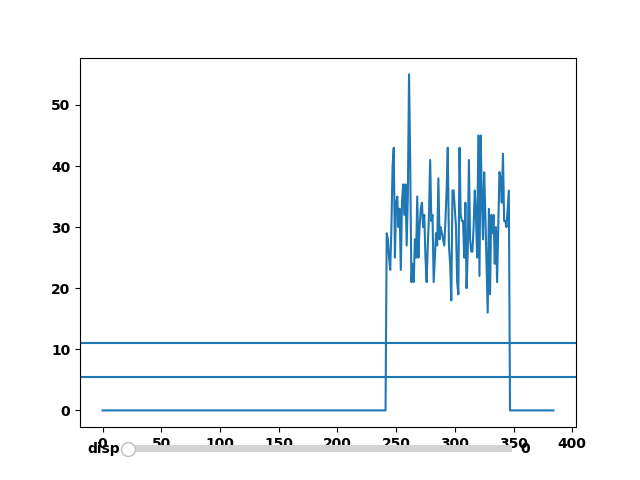

In [39]:
#visualise the data at any dispersion pixel to check the thresholds
fig,ax = plt.subplots()
fctr_low = 0.1
fctr_high = 0.2
lines=[ax.plot(flat_data[0]),ax.axhline(y=fctr_low*max(flat_data[0])),ax.axhline(y=fctr_high*max(flat_data[0]))]
ax_slider = fig.add_axes([0.2, 0.05, 0.6, 0.03])
disp_slider = Slider(ax=ax_slider,valmin=0,valmax=len(flat_data[:,0])-1,valinit=0,label='disp')
def update(val):
    val=int(val)
    lines[0][0].set_ydata(flat_data[val])
    lines[1].set_ydata([fctr_low*max(flat_data[val]),fctr_low*max(flat_data[val])])
    lines[2].set_ydata([fctr_high*max(flat_data[val]),fctr_high*max(flat_data[val])])
    ax.relim()
    ax.autoscale_view()
    fig.canvas.draw_idle()

disp_slider.on_changed(update)

In [40]:
#intialise lists of the edges and the disperson pixel they are found at
left_edges = []
right_edges = []
idxs = []
for i, row in enumerate(flat_data):
    #find the edges as the pixels where the intensity is between a low threshold and a high threshold as found above
    threshold_low = 0.1*np.max(row)
    threshold_high = 0.2*np.max(row)
    tracks, = np.where((row<threshold_high) & (row>threshold_low))
    #reject dispersion pixels where there are not two clean tracks
    if len(tracks) != 2:
        continue
    #reject dispersion pixels where only one track was detected
    if abs(tracks[0]-tracks[1])<15:
        continue
    #add the cordinates to the lists
    left_edges.append(min(tracks))
    right_edges.append(max(tracks))
    idxs.append(i)

In [41]:
#check what the best polynomial fit is. by visual inspection it is likely to be order 2, so only check order 0-4
for order in range(5):
    left_p = np.polyfit(idxs,left_edges,order)
    right_p = np.polyfit(idxs,right_edges,order)
    left_model = np.polyval(left_p,idxs)
    right_model = np.polyval(right_p,idxs)
    chi2_left = np.sum((left_model-left_edges)**2)
    chi2_right = np.sum((right_model-right_edges)**2)
    print(order)
    print(f"left RSS: {chi2_left}")
    print(f"right RSS: {chi2_right}")

0
left RSS: 4152222.938202247
right RSS: 4124594.488764045
1
left RSS: 475709.78435223945
right RSS: 467504.5336269655
2
left RSS: 39.71236129465386
right RSS: 155.0262890484903
3
left RSS: 24.15891021196955
right RSS: 148.03835211531282
4
left RSS: 22.964639612228105
right RSS: 147.21968155712602


as per the previous cell, a 2nd degree polynomial provides a much better fit than liner or constant fits, but higher order polynomials do not provide a meaningful increace in goodness of fit for the extra comptaitional cost

In [42]:
#fit a quadratic to each of the tracks
left_p = np.polyfit(idxs,left_edges,2)
right_p = np.polyfit(idxs,right_edges,2)

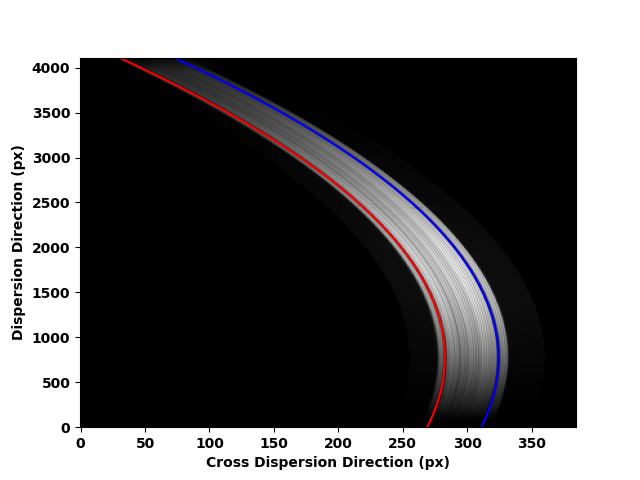

In [43]:
#plot the data and the quadratics fit for the tramtracks
fig,ax = plt.subplots()
ax.imshow(flat_data,aspect='auto',cmap='grey')
idxs = range(len(flat_data[:,0]))
ax.plot(np.polyval(left_p,idxs),idxs,c='r')
ax.plot(np.polyval(right_p,idxs),idxs,c='b')
ax.set_xlabel('Cross Dispersion Direction (px)')
ax.set_ylabel('Dispersion Direction (px)')
ax.invert_yaxis()
fig.savefig('figures/tramtracks.png')

In [44]:
#import the moon data from the fits and inspect it
moon_hudl = fits.open(r'data\moon.fits')
print(moon_hudl)
print(moon_hudl[0].header)
print(moon_hudl[0].data)
moon_data = moon_hudl[0].data

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  385                                                  NAXIS2  =                 4112                                                  EXTEND  =                    T                                                  END                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [45]:
#construct a mask on the data to isolate the space between the tramtracks
spec_mask = np.zeros_like(moon_data)
cross_disp_grid = np.arange(0,moon_data.shape[1],1)
left_track = np.polyval(left_p,np.arange(0,moon_data.shape[0],1))
right_track = np.polyval(right_p,np.arange(0,moon_data.shape[0],1))
for i,row in enumerate(spec_mask):
    row[(cross_disp_grid>left_track[i]) & (cross_disp_grid<right_track[i])] = 1
spec_mask = spec_mask.astype(bool)

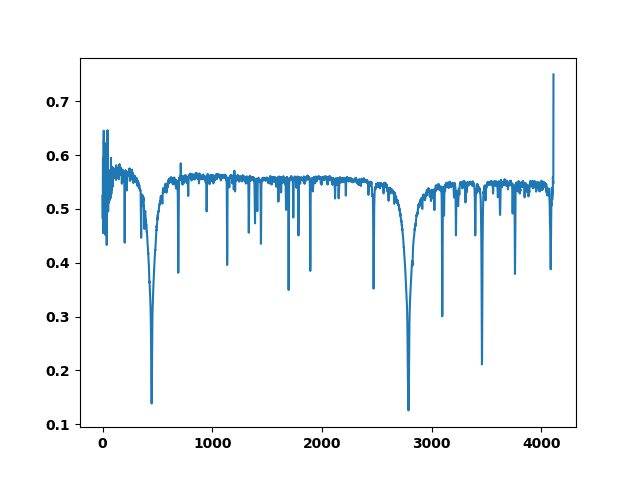

In [46]:
#use the mask to replace all data outside the tramlines with NaN
moon_spec_data = np.where(spec_mask,moon_data,np.nan)
flat_spec_data = np.where(spec_mask,flat_data,np.nan)
#sum the remaining moon data and normalize by the flat data
moon_spec = np.nansum(moon_spec_data,axis=1)/np.nansum(flat_spec_data,axis=1)
#plot the spectrum
fig,axs = plt.subplots()
axs.plot(moon_spec)

In [47]:
#find the center of the three features. by inspection, it is likely the three strongest featues as they have the same shape and are in approximetaly the correct places.
features, = np.where(moon_spec<0.6*np.median(moon_spec))
print(features)
feature_1_center = np.median(features[:20])
feature_2_center = np.median(features[21:39])
feature_3_center = np.median(features[-6:])
print(feature_2_center)
print(feature_1_center)
print(feature_3_center)
#check the fetures are in the correct place
print((feature_1_center-feature_2_center)/(feature_2_center-feature_3_center))
print(((8662-8542)/(8542-8498)))


[ 436  437  438  439  440  441  442  443  444  445  446  447  448  449
  450  451  452  453  454  455  456  457  458 2775 2776 2777 2778 2779
 2780 2781 2782 2783 2784 2785 2786 2787 2788 2789 2790 2791 2792 2793
 2794 2795 2796 2797 2798 2799 2800 2801 2802 2803 3097 3098 3457 3458
 3459 3460 3461 3462]
2781.5
445.5
3459.5
3.4454277286135695
2.727272727272727


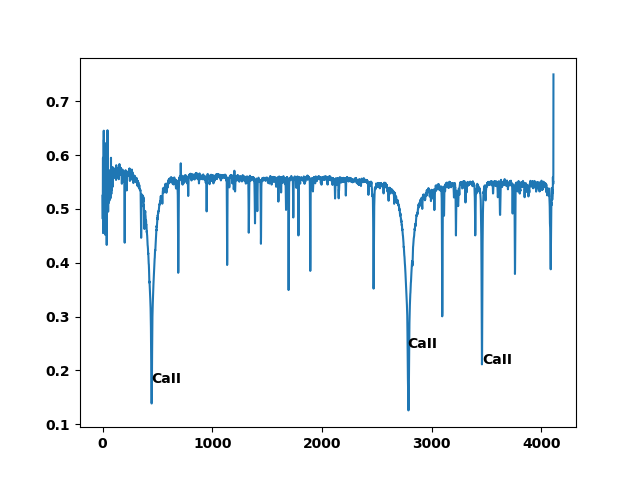

In [48]:
#label the features on the plot.
for center in [feature_1_center,feature_2_center,feature_3_center]:
    axs.annotate("CaII",(center,moon_spec[int(center)]))
fig.show()
fig.savefig('figures/moon_spec.png')